In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the datasets
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
txn = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")
holdings = pd.read_csv("../data/processed/09_portfolio_holdings_cleaned.csv")
fund_master = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")

In [3]:
nav["date"] = pd.to_datetime(nav["date"])
nav = nav.sort_values(["amfi_code","date"])
nav["daily_return"] = (nav.groupby("amfi_code")["nav"].pct_change())
#pct_change() calculates the percentage change between the current and a prior element. 


In [5]:
# Calculate VaR and CVaR for each fund
var_data = []
for code in nav["amfi_code"].unique():
    returns = nav[nav["amfi_code"] == code]["daily_return"].dropna()
    # VaR at 95% confidence level
    var95 = np.percentile(returns,5)
    # CVaR is the average of returns that are less than or equal to the VaR
    cvar95 = returns[returns <= var95].mean()
    var_data.append([code,var95,cvar95])

var_cvar_df = pd.DataFrame(
    var_data,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)
var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [6]:
# Export VaR Report
var_cvar_df.to_csv( "../reports/var_cvar_report.csv",index=False)
print("Saved")

Saved


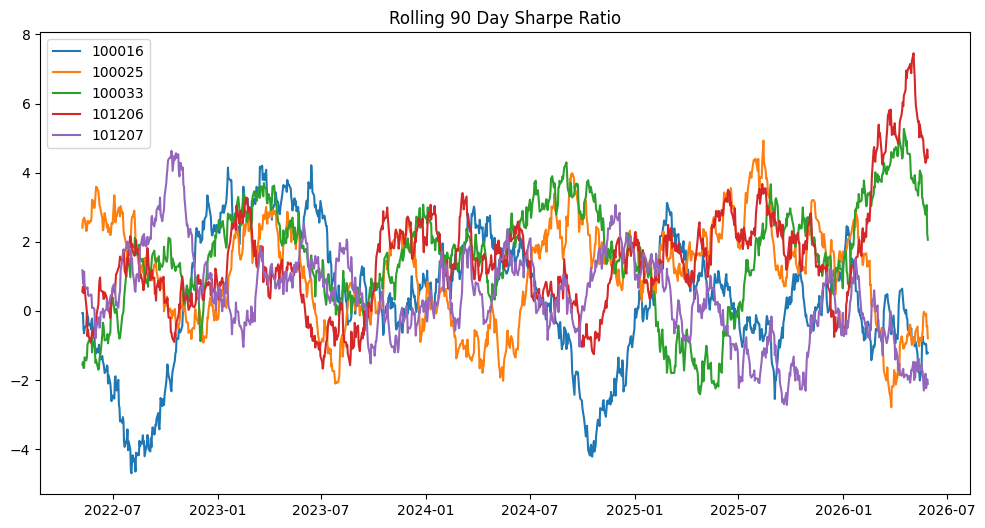

In [ ]:
# Plot rolling 90 day Sharpe ratio for top 5 funds by number of records
top5 = nav["amfi_code"].unique()[:5]
plt.figure(figsize=(12,6))
for code in top5:
    temp = nav[nav["amfi_code"] == code].copy()
    rolling_sharpe = (temp["daily_return"].rolling(90).mean()/temp["daily_return"].rolling(90).std()) * np.sqrt(252)
    plt.plot(temp["date"],rolling_sharpe,label=str(code))

plt.title("Rolling 90 Day Sharpe Ratio")
plt.legend()
plt.show()

In [8]:
# Save the plot
plt.savefig("../reports/rolling_sharpe_chart.png")

<Figure size 640x480 with 0 Axes>

In [15]:
# Cohort Analysis
txn["transaction_date"] = pd.to_datetime(txn["transaction_date"])
txn["cohort_year"] = (txn.groupby("investor_id")["transaction_date"].transform("min").dt.year)

cohort = txn.groupby( "cohort_year").agg(avg_sip_amount=("amount_inr","mean"),total_invested=("amount_inr","sum"))
cohort

,avg_sip_amount,total_invested
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


In [ ]:
# Top funds by cohort
top_fund = txn.groupby(["cohort_year","amfi_code"]).size().reset_index(name="count")
top_fund = top_fund.sort_values(["cohort_year","count"],ascending=[True,False])
top_fund.head(10)

,cohort_year,amfi_code,count
35,2024,148568,874
33,2024,125498,869
24,2024,120504,864
17,2024,119095,857
13,2024,118636,850
19,2024,119551,847
4,2024,101207,844
16,2024,119094,840
32,2024,125497,840
5,2024,101208,832


In [ ]:
# SIP frequency analysis
sip = txn[txn["transaction_type"] == "SIP"].copy()
sip = sip.sort_values(["investor_id","transaction_date"])
sip["gap_days"] = sip.groupby("investor_id")["transaction_date"].diff().dt.days

In [ ]:
# Identify investors with average gap > 35 days and at least 6 SIP transactions
risk_investors = sip.groupby("investor_id").agg(avg_gap=("gap_days","mean"),sip_count=("gap_days","count"))
risk_investors = risk_investors[risk_investors["sip_count"] >= 6]
risk_investors["status"] = np.where(risk_investors["avg_gap"] > 35,"At Risk","Healthy")
risk_investors.head()

,avg_gap,sip_count,status
investor_id,,,
INV000011,40.166667,6,At Risk
INV000012,57.000000,7,At Risk
INV000013,55.333333,6,At Risk
INV000014,75.333333,6,At Risk
INV000023,58.571429,7,At Risk


In [ ]:
scorecard = pd.read_csv("../reports/day4_fund_scorecard.csv")

scorecard.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score
0,120505,30.353412,30.206535,NaN,1.180101,0.292636,0.000549,-0.181885,1.36,0.900,0.900,0.950,0.65,0.625,84.500
1,100033,47.734590,33.629211,NaN,1.093699,0.271954,0.005104,-0.162172,1.38,0.975,0.850,0.875,0.60,0.500,82.000
2,119094,30.918202,36.066017,NaN,0.998231,0.260767,-0.066265,-0.209609,1.38,1.000,0.750,0.800,0.60,0.700,80.750
3,119598,84.532246,27.814418,NaN,0.945308,0.303370,-0.023196,-0.287060,1.43,0.850,0.675,1.000,0.50,0.900,78.875
4,148567,14.580715,31.278573,NaN,1.448291,0.269838,0.023684,-0.112657,1.46,0.925,1.000,0.850,0.45,0.200,78.500


In [26]:
sharpe_df = scorecard[
    [
        "amfi_code",
        "sharpe_ratio"
    ]
]

sharpe_df.head()

,amfi_code,sharpe_ratio
0,120505,1.180101
1,100033,1.093699
2,119094,0.998231
3,119598,0.945308
4,148567,1.448291


In [27]:
risk_map = {
    "Low": ["Low", "Low to Moderate"],
    "Moderate": ["Moderate"],
    "High": ["Moderately High", "High", "Very High"]
}

In [ ]:
# Map the risk categories to the scorecard
recommender_df = sharpe_df.merge(
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "risk_category"
        ]
    ],
    on="amfi_code"
)

recommender_df.head()

,amfi_code,sharpe_ratio,scheme_name,risk_category
0,120505,1.180101,ICICI Pru Midcap Fund - Regular - Growth,High
1,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,High
2,119094,0.998231,Axis Midcap Fund - Regular - Growth,High
3,119598,0.945308,SBI Small Cap Fund - Regular Plan - Growth,Very High
4,148567,1.448291,Mirae Asset Large Cap Fund - Regular - Growth,Moderate


In [ ]:
# Function to recommend top 3 funds based on risk level
def recommend_funds(risk_level):
    eligible = recommender_df[recommender_df["risk_category"].isin(risk_map[risk_level])]
    return eligible.sort_values("sharpe_ratio",ascending=False).head(3)[["scheme_name","risk_category","sharpe_ratio"]]

In [ ]:
# Example 
recommend_funds("Moderate")

,scheme_name,risk_category,sharpe_ratio
4,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.448291
8,SBI Bluechip Fund - Regular Plan - Growth,Moderate,1.208267
12,Nippon India Large Cap Fund - Regular - Growth,Moderate,1.081659


In [ ]:
# Calculate HHI for each fund
hhi_data = []
for code in holdings["amfi_code"].unique():
    temp = holdings[holdings["amfi_code"] == code]
    hhi =((temp["weight_pct"] / 100) ** 2).sum()
    hhi_data.append([code, hhi])

hhi_df = pd.DataFrame(
    hhi_data,
    columns=[
        "amfi_code",
        "HHI"
    ])
hhi_df.head()

,amfi_code,HHI
0,119551,0.118716
1,119552,0.108011
2,119598,0.107349
3,119599,0.174751
4,100016,0.139534


In [33]:
# Top 10 funds by HHI
hhi_df.sort_values("HHI",ascending=False).head(10)

,amfi_code,HHI
19,119092,0.206448
24,101207,0.200700
3,119599,0.174751
25,102885,0.174709
12,118632,0.168298
29,148568,0.167930
10,120505,0.157570
11,120506,0.153794
7,125498,0.152414
16,120841,0.149680


In [39]:
cohort

,avg_sip_amount,total_invested
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


# Advanced Insights
### 1. Highest Downside Risk Funds
Funds with AMFI codes 119599, 119095, and 101207 recorded the lowest VaR values (approximately -2.6%), indicating higher downside risk during adverse market movements.

### 2. Severe Tail Losses
CVaR analysis showed that the worst-performing funds experienced average losses of around -3.0% to -3.2% on days beyond the VaR threshold, highlighting significant tail risk.

### 3. Investor Cohort Behaviour
The 2024 investor cohort contributed the highest total investment amount of approximately ₹349.1 Crore, substantially exceeding the 2025 cohort's contribution of approximately ₹3.05 Crore.

### 4. SIP Continuity Risk
Among investors with at least 6 SIP transactions, 813 were classified as "At Risk" while only 21 were classified as "Healthy", suggesting a high likelihood of SIP discontinuation among a large portion of investors.

### 5. Portfolio Concentration and Fund Recommendations
Funds with AMFI codes 119092 and 101207 had the highest HHI scores, indicating concentrated portfolios. For moderate-risk investors, Mirae Asset Large Cap Fund, SBI Bluechip Fund, and Nippon India Large Cap Fund emerged as the top recommendations based on Sharpe Ratio.